<a href="https://colab.research.google.com/github/QuirozAlaniz/Evaluacion_Analisis_Descriptivo/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Francisco Daniel Quiroz Alaniz
- **Matrícula:** 269723

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [9]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.
print("Media:", df["price"].mean() )
print("Mediana:", df["price"].median() )
print("Moda:", df["price"].mode() )



Media: 152.7206871868289
Mediana: 106.0
Moda: 0    100
Name: price, dtype: int64


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_
\
La media y la mediana no están tan cerca, difieren en 46 puntos, eso nos indica que hay algunos outliers que hacen que la media se vea afectada, pues es sensible a estos valores.
\
Llama la atención que la moda es 100, valor que se acerca más a la mediana que a la media, un argumento más para señalar que la media está muy influida por los valores extremos.


---
## Actividad 2 — Dispersión (20 pts)

In [11]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.
rango = df["price"].max() - df["price"].min()
varianza = df["price"].var()
desviacion = df["price"].std()
Q1 = df["price"].quantile(0.25)
Q2 = df["price"].quantile(0.5)
Q3 = df["price"].quantile(0.75)
IQR = Q3-Q1
maximo = df["price"].max()
print(f'Rango:    {rango:,.2f} ')
print(f'Varianza:  {varianza:,.2f}')
print(f'Desviación:  {desviacion:,.2f}')
print(f'Q1: {Q1:,.2f}')
print(f'Q2: {Q2:,.2f}')
print(f'Q3: {Q3:,.2f}')
print(f'IQR: {IQR:,.2f}')
print(f'maximo: {maximo:,.2f}')


Rango:    10,000.00 
Varianza:  57,674.03
Desviación:  240.15
Q1: 69.00
Q2: 106.00
Q3: 175.00
IQR: 106.00
maximo: 10,000.00


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_
\
El IQR es definitivamente más representativo que el Rango, debido a que como hay una distancia enorme entre el valor mínimo y el máximo, el Rango crece muchísimo, de hecho coincide con el valor máximo de los datos sin embargo el IQR, que ignora el 25% más bajo y el 25% más alto, describe mejor la dispersión de la mayoría de los datos.


---
## Actividad 3 — Forma (20 pts)

In [12]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
print('Asimetría:', df["price"].skew() )    #Calculaos la asimetría
print("Curtosis:", df["price"].kurt() )     #Calculamos la curtosis



Asimetría: 19.118938995046033
Curtosis: 585.6728788988286


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_
\
Como la asimetría es 19 (alta) y mayor a 0, la gran masa de datos se inclina hacia la izquierda con una "cola" a la derecha, mientras que la Curtosis es muy grande debido a que hay valores extremos como podemos constatar en el Rango. Pasa algo similar a lo que pasó en la columna "Income" vista en clase, solo que magnificado, en aquél la curtosis no eran tan grande como en este caso porque no había tantos valores atícos.
\
En la próxima etapa de Datos Atípicos espero ver uno o algunos datos extremos, quizás incluso outliers.

---
## Actividad 4 — Visualización (30 pts)

<Axes: ylabel='Frequency'>

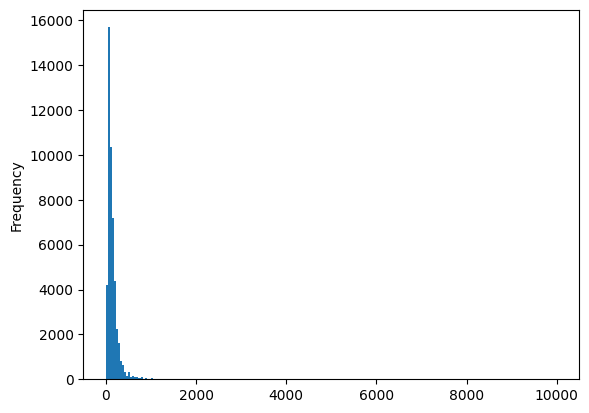

In [13]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.
barras = round((len(df["price"]))**.5)
df["price"].plot(kind = "hist", bins = barras )


Explicación.
\
Una regla común es sacar raíz cuadrada al número de datos para elegir el número de bins en un histograma, lo cual nos da un número proporcional a la cantidad de datos, por eso elegí esa regla.
\
Hay que redondear el número porque el número de bins debe ser un entero.
\
En el histograma podemos observar que los datos están recargados a la izquierda, incluso se pueden ver variaciones entre el 0 y el 1000, pero como hay datos hasta el 10000, el histograma no puede ignorarlos y por eso se extiende hasta la derecha hasta este valor.

Text(0, 0.5, 'Frecuencia')

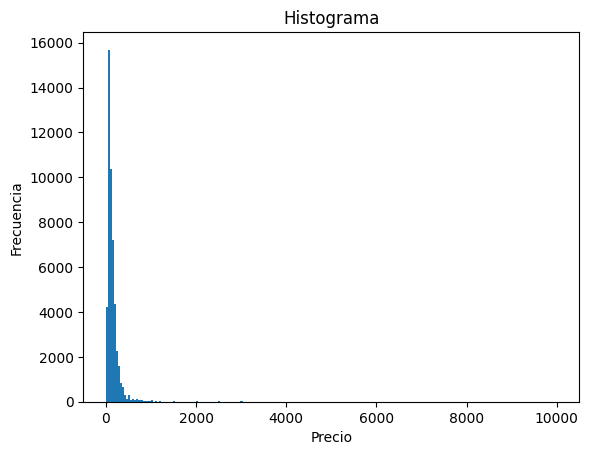

In [14]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.
fig = plt.figure()
plt.hist(df["price"], bins = barras)
plt.title("Histograma")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")


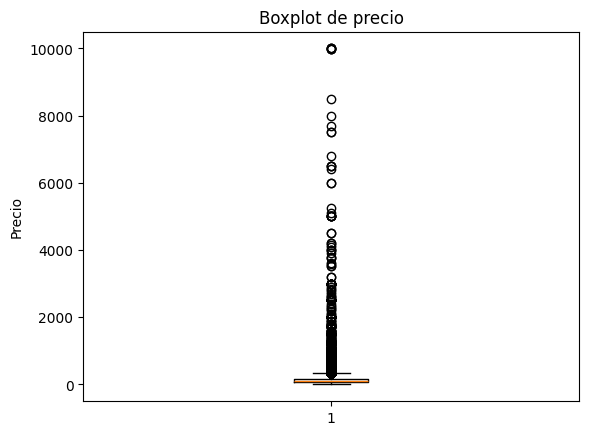

In [15]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).
fig = plt.figure()
plt.boxplot(df["price"])
plt.title("Boxplot de precio")
plt.ylabel("Precio")
plt.show()



**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_
\
Observo que la gran mayoría de los valores están concentrados en la parte baja del boxplot, desde 0 a 4000, mientras que arriba de éste último valor hay solamente unos pocos dispersos, hasta uno que llega a ser 10000.
\
A diferencia del histograma, aquí se ven claramente los valores extremos, en el histograma, al graficar las frecuencias, el valor extremo de 10000 no se ve para nada, porque en comparación con los demás no se ve el área que ocupa.
\
Definitivamente los valores, como lo muestra la asimetría tiene una cola muy larga hacia la derecha hasta alcanzar el valor de 10000, mientras que la curtosis ya anunciaba la presencia de ese 10000 y otros valores extremos.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_
\
El precio promedio de 152.72 es engañoso en este caso porque no representa a la mayoría de los datos al ser ésta influida enormemente por valores atípicos y outliers. La distribución tiene una cola muy larga hacia la derecha, como se ve en el boxplot, incluso en el histograma al extenderse hacia 10000 da una pista de eso, aunque no se ve claramente la altura que levanta la barra.
\
Si queremos un valor que generalice, usaría mejor la mediana porque la mayoría de los valores se mueven alrededor de la misma.

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |